In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


In [2]:

# Load dataset
df = pd.read_csv("user-data.csv")
df

,user_id,gender,age,estimated_salary,purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:

# Features and target
X = df.iloc[:, [2, 3]].values  # Age, Estimated Salary
y = df.iloc[:, 4].values       # Purchased

In [4]:
X

array([[    19,  19000],
       [    35,  20000],
       [    26,  43000],
       [    27,  57000],
       [    19,  76000],
       [    27,  58000],
       [    27,  84000],
       [    32, 150000],
       [    25,  33000],
       [    35,  65000],
       [    26,  80000],
       [    26,  52000],
       [    20,  86000],
       [    32,  18000],
       [    18,  82000],
       [    29,  80000],
       [    47,  25000],
       [    45,  26000],
       [    46,  28000],
       [    48,  29000],
       [    45,  22000],
       [    47,  49000],
       [    48,  41000],
       [    45,  22000],
       [    46,  23000],
       [    47,  20000],
       [    49,  28000],
       [    47,  30000],
       [    29,  43000],
       [    31,  18000],
       [    31,  74000],
       [    27, 137000],
       [    21,  16000],
       [    28,  44000],
       [    27,  90000],
       [    35,  27000],
       [    33,  28000],
       [    30,  49000],
       [    26,  72000],
       [    27,  31000],


In [5]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [6]:

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:

# Train SVM
model = SVC(kernel="linear", random_state=0)
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [8]:


# Predict
y_pred = model.predict(X_test)

Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        68
           1       0.92      0.75      0.83        32

    accuracy                           0.90       100
   macro avg       0.91      0.86      0.88       100
weighted avg       0.90      0.90      0.90       100



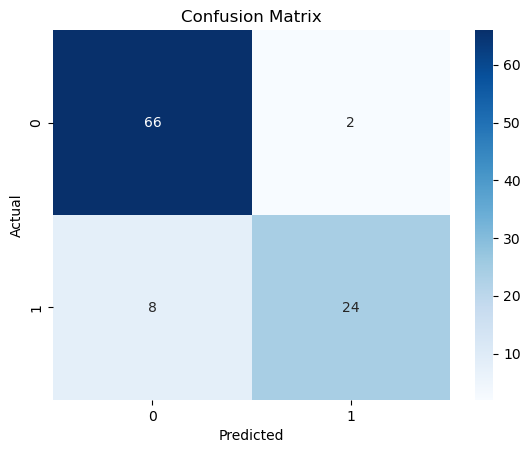

In [9]:

# Accuracy and confusion matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Function to plot decision boundaries

In [10]:

def plot_decision_boundary(X_set, y_set, title):
    X1, X2 = np.meshgrid(
        np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
        np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
    )
    
    plt.figure(figsize=(8,6))
    plt.contourf(
        X1, X2,
        model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
        alpha=0.3,
        cmap=ListedColormap(('red', 'green'))
    )
    
    colors = ['red', 'green']
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j, 0],
            X_set[y_set == j, 1],
            c=colors[i],
            label=f'Class {j}',
            edgecolor='k',
            s=50
        )
    
    plt.title(title)
    plt.xlabel('Age (scaled)')
    plt.ylabel('Estimated Salary (scaled)')
    plt.legend()
    plt.show()



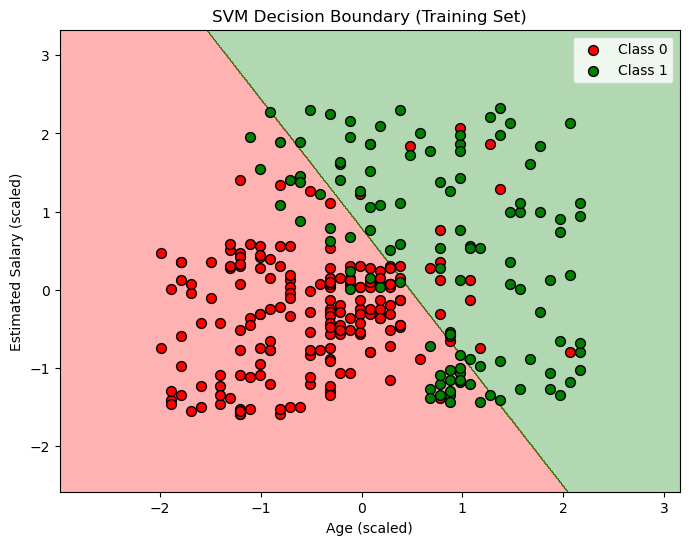

In [11]:
# Plot for Training set
plot_decision_boundary(X_train, y_train, "SVM Decision Boundary (Training Set)")


In [ ]:

# Plot for Test set
plot_decision_boundary(X_test, y_test, "SVM Decision Boundary (Test Set)")


# Steps 

Make a grid of all possible feature values.

Use the SVM model to predict class for every point in the grid.

Color the background depending on the predicted class.

Overlay real data points on top of the background.

Add labels and legend for clarity.

# Create a grid for plotting

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

np.meshgrid creates a grid of points that covers the entire feature space.

X1 → all the values along the first feature (Age).

X2 → all the values along the second feature (Salary).

step=0.01 → small step to make the decision boundary smooth.

Basically: it’s like plotting a background canvas for the classifier.

# Plot the decision boundary


plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(('red', 'green'))
)


X1.ravel() and X2.ravel() → flatten the grid into a long list of points.

model.predict(...) → predict class (0 or 1) for every point in the grid.

.reshape(X1.shape) → reshape it back to grid shape.

plt.contourf → fills areas with colors:

    Red → Class 0
    
    Green → Class 1

alpha=0.3 → makes the background slightly transparent so points stand out.

# Plot actual points


colors = ['red', 'green']
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=colors[i],
        label=f'Class {j}',
        edgecolor='k',
        s=50
    )


Loop through each class (0 and 1).

X_set[y_set == j, 0] → all x-values (Age) for that class.

X_set[y_set == j, 1] → all y-values (Salary) for that class.

plt.scatter → plots the real data points on top of the background.

edgecolor='k' → black border around points so they stand out.

s=50 → size of points.